In [2]:
import numpy as np
import pandas as pd

from geopy.geocoders import Nominatim

from math import radians, cos, sin, asin, sqrt
import googlemaps
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
yerevan_historical = pd.read_excel('../data/raw_data/Yerevan historical.xlsx')

In [40]:
yerevan_historical = yerevan_historical[(yerevan_historical['backup_status'] == "sold") & ((yerevan_historical['rent_or_sale'] == "sale appartments") | (yerevan_historical['rent_or_sale'] == "sale houses"))]

yerevan_historical['date'] = pd.to_datetime(yerevan_historical['date'], format='%Y-%m-%d')

,OBJECTID,level_0,backup_status,index,id,price,rooms,square_meters,address,date,...,building_floors,height,bathroom,rent_or_sale,links,download_date,days_in,years_moths,y,x
0,1,0,sold,0,18793673,46000.0,2.0,NaN,Yerevan › Shengavit,2023-03-14 15:26:36,...,6,2.60,1.0,sale appartments,http://list.am/en/item/18793673,2023-01-03 17:32:32,69.0,2023_1,44.490789,40.148496
1,2,2,sold,2,18920910,67000.0,2.0,NaN,"Svachyan street, Yerevan",2023-03-14 15:26:36,...,9,2.75,1.0,sale appartments,http://list.am/en/item/18920910,2023-02-13 09:35:17,29.0,2023_2,44.445433,40.175106
2,3,3,sold,3,16513238,NaN,3.0,NaN,"Մարշալ Բաղրամյան պողոտա 2/5, Երևան",2023-03-14 15:26:36,...,2,2.75,2.0,sale appartments,http://list.am/en/item/16513238,2022-08-28 21:21:50,197.0,2022_8,44.514109,40.188914
3,4,4,sold,4,18489003,345000.0,5.0,NaN,Yerevan › Kentron,2023-03-14 15:26:36,...,5,3.50,1.0,sale appartments,http://list.am/en/item/18489003,2022-11-01 17:49:54,132.0,2022_11,44.514720,40.182989
4,5,5,sold,5,18760698,185000.0,3.0,NaN,"Մարշալ Բաղրամյան պողոտա 56, Yerevan",2023-03-14 15:26:36,...,5,3.20,1.0,sale appartments,http://list.am/en/item/18760698,2023-01-03 17:42:37,69.0,2023_1,44.499054,40.193289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729490,729491,860831,sold,41703,11263097,65000.0,3.0,250.0,"Tserents Street, Yerevan",2022-08-08 20:25:49,...,NaN,NaN,1.0,sale houses,http://list.am/en/item/11263097,2022-09-09 17:43:06,32.0,2022_9,44.454758,40.166871
729491,729492,860836,sold,41708,17735651,60000.0,4.0,92.0,Yerevan › Kentron,2022-08-08 20:25:49,...,NaN,NaN,1.0,sale houses,http://list.am/en/item/17735651,NaN,NaN,None_None,44.514720,40.182989
729494,729495,860847,sold,41719,17934152,450000.0,5.0,400.0,"Noy District, Yerevan",2022-08-08 20:25:49,...,NaN,NaN,3.0,sale houses,http://list.am/en/item/17934152,2022-11-25 10:26:06,109.0,2022_11,44.468143,40.185407
729495,729496,860848,sold,41720,17847488,1300.0,5.0,152.0,Yerevan › Avan,2022-08-08 20:25:49,...,NaN,NaN,2.0,sale houses,http://list.am/en/item/17847488,NaN,NaN,None_None,44.561271,40.219372


In [41]:
houses_filt = yerevan_historical.dropna(subset=['price'])

In [42]:
filtered_df = houses_filt.loc[houses_filt.groupby('id')['date'].idxmax()].reset_index(drop=True)

,OBJECTID,level_0,backup_status,index,id,price,rooms,square_meters,address,date,...,building_floors,height,bathroom,rent_or_sale,links,download_date,days_in,years_moths,y,x
0,700755,822551,sold,3423,316,500000.0,4.0,150.0,"Yerevan, Erebuni, Davit Bek St",2022-08-08 20:25:49,...,NaN,3.2,3.0,sale houses,https://www.real-estate.am/en/house-for-sale/D...,NaN,NaN,None_None,44.524808,40.148482
1,481959,552379,sold,2161,1055,130000.0,2.0,50.0,"Yerevan, Center, Vardanants St",2022-10-08 21:56:34,...,10,2.8,1.0,sale appartments,https://www.real-estate.am/en/1-bedroom/apartm...,2022-09-10 02:04:46,28.0,2022_9,44.521089,40.174314
2,699792,821557,sold,2429,1991,95000.0,2.0,56.0,"Yerevan, Arabkir, V.Papazyan St",2022-08-08 20:25:49,...,5,2.8,1.0,sale appartments,https://www.real-estate.am/en/1-bedroom/apartm...,NaN,NaN,None_None,44.502252,40.204200
3,700740,822536,sold,3408,3113,918000.0,4.0,600.0,"Yerevan, Arabkir, Babayan St",2022-08-08 20:25:49,...,NaN,3.2,3.0,sale houses,https://www.real-estate.am/en/house-for-sale/B...,NaN,NaN,None_None,44.519823,40.199158
4,482385,552814,sold,587,3119,400000.0,4.0,1150.0,"Yerevan, Vahagni district, Narekaci st",2022-10-08 21:56:34,...,NaN,3.2,3.0,sale houses,https://www.real-estate.am/en/house-for-sale/N...,2022-09-25 12:31:44,13.0,2022_9,44.448497,40.220040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88572,45120,54101,sold,851,19124548,990000.0,5.0,NaN,"Հյուսիսային ճառագայթ փողոց 1, Երևան",2023-03-14 15:26:36,...,NaN,NaN,3.0,sale houses,http://list.am/en/item/19124548,2023-03-14 12:17:35,0.0,2023_3,44.516131,40.199785
88573,45113,54087,sold,837,19124552,210000.0,5.0,NaN,"Պարսեղովի փողոց, Երևան",2023-03-14 15:26:36,...,NaN,NaN,2.0,sale houses,http://list.am/en/item/19124552,2023-03-14 11:47:42,0.0,2023_3,44.471134,40.199275
88574,45093,54029,sold,779,19124632,300000.0,4.0,NaN,"Ezras Hasratyan Street 32/20, Yerevan",2023-03-14 15:26:36,...,NaN,NaN,2.0,sale houses,http://list.am/en/item/19124632,2023-03-14 11:43:07,0.0,2023_3,44.537852,40.214862
88575,44758,53371,sold,121,19125622,215000.0,4.0,NaN,"Քանաքեռ 9-րդ փողոց 15/1, Երևան",2023-03-14 15:26:36,...,NaN,NaN,2.0,sale houses,http://list.am/en/item/19125622,2023-03-14 11:35:27,0.0,2023_3,44.546763,40.185311


## Haversine and Actual walking distance

In [44]:
# Define a function to calculate the Haversine distance between two points
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # Convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # Haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles
    return c * r

def get_walking_distance(start_lon, start_lat, end_lon, end_lat):
    # Set up the Google Maps API client
    gmaps = googlemaps.Client(key='***REMOVED-GOOGLE-API-KEY***')

    # Define the start and end coordinates
    start = (start_lat, start_lon)
    end = (end_lat, end_lon)

    # Make the API request
    now = datetime.now()
    directions = gmaps.directions(start, end, mode='walking', departure_time=now)

    # Extract the distance from the response
    distance = directions[0]['legs'][0]['distance']['value']

    # Return the distance in meters
    return distance

In [45]:
# Metro Stations in Yerevan
stations = pd.DataFrame({
    'station_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'station_name': ['Barekamutyun', 'Baghramyan', 'Yeritasardakan', 'Republic Square', 'Zoravar Andranik', 'Sasuntsi Davit', 'Gortsaranain','Shengavit', 'Charbakh', 'Garegin Nzhdeh Square'],
    'x': [40.197446,40.1918167,40.1873081, 40.1785331, 40.1699272, 40.1552243, 40.1410611, 40.145224, 40.1405941, 40.1504761],
    'y': [44.493467,44.5038091, 44.5191743, 44.5134433, 44.5112603, 44.5058011, 44.4964173, 44.48483, 44.4685333, 44.4816183]
})

In [46]:
# Loop through each house and station to find the shortest distance using Haversine
distances = []
station_ids = []
station_names = []
for house_idx, house in filtered_df.iterrows():
    shortest_distance = float('inf')
    nearest_station_name = ''
    for station_idx, station in stations.iterrows():
        distance = haversine(house['y'], house['x'], station['y'], station['x'])
        if distance < shortest_distance:
            shortest_distance = distance
            nearest_station_id = station['station_id']
            nearest_station_name = station['station_name']
    #distances.append(shortest_distance)
    station_ids.append(nearest_station_id)
    station_names.append(nearest_station_name)

# Add the new columns to the houses table
#houses['shortest_distance'] = distances
filtered_df['nearest_station_id'] = station_ids
filtered_df['nearest_station_name'] = station_names

,OBJECTID,level_0,backup_status,index,id,price,rooms,square_meters,address,date,...,bathroom,rent_or_sale,links,download_date,days_in,years_moths,y,x,nearest_station_id,nearest_station_name
0,700755,822551,sold,3423,316,500000.0,4.0,150.0,"Yerevan, Erebuni, Davit Bek St",2022-08-08 20:25:49,...,3.0,sale houses,https://www.real-estate.am/en/house-for-sale/D...,NaN,NaN,None_None,44.524808,40.148482,6,Sasuntsi Davit
1,481959,552379,sold,2161,1055,130000.0,2.0,50.0,"Yerevan, Center, Vardanants St",2022-10-08 21:56:34,...,1.0,sale appartments,https://www.real-estate.am/en/1-bedroom/apartm...,2022-09-10 02:04:46,28.0,2022_9,44.521089,40.174314,4,Republic Square
2,699792,821557,sold,2429,1991,95000.0,2.0,56.0,"Yerevan, Arabkir, V.Papazyan St",2022-08-08 20:25:49,...,1.0,sale appartments,https://www.real-estate.am/en/1-bedroom/apartm...,NaN,NaN,None_None,44.502252,40.204200,1,Barekamutyun
3,700740,822536,sold,3408,3113,918000.0,4.0,600.0,"Yerevan, Arabkir, Babayan St",2022-08-08 20:25:49,...,3.0,sale houses,https://www.real-estate.am/en/house-for-sale/B...,NaN,NaN,None_None,44.519823,40.199158,3,Yeritasardakan
4,482385,552814,sold,587,3119,400000.0,4.0,1150.0,"Yerevan, Vahagni district, Narekaci st",2022-10-08 21:56:34,...,3.0,sale houses,https://www.real-estate.am/en/house-for-sale/N...,2022-09-25 12:31:44,13.0,2022_9,44.448497,40.220040,1,Barekamutyun
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88572,45120,54101,sold,851,19124548,990000.0,5.0,NaN,"Հյուսիսային ճառագայթ փողոց 1, Երևան",2023-03-14 15:26:36,...,3.0,sale houses,http://list.am/en/item/19124548,2023-03-14 12:17:35,0.0,2023_3,44.516131,40.199785,2,Baghramyan
88573,45113,54087,sold,837,19124552,210000.0,5.0,NaN,"Պարսեղովի փողոց, Երևան",2023-03-14 15:26:36,...,2.0,sale houses,http://list.am/en/item/19124552,2023-03-14 11:47:42,0.0,2023_3,44.471134,40.199275,1,Barekamutyun
88574,45093,54029,sold,779,19124632,300000.0,4.0,NaN,"Ezras Hasratyan Street 32/20, Yerevan",2023-03-14 15:26:36,...,2.0,sale houses,http://list.am/en/item/19124632,2023-03-14 11:43:07,0.0,2023_3,44.537852,40.214862,3,Yeritasardakan
88575,44758,53371,sold,121,19125622,215000.0,4.0,NaN,"Քանաքեռ 9-րդ փողոց 15/1, Երևան",2023-03-14 15:26:36,...,2.0,sale houses,http://list.am/en/item/19125622,2023-03-14 11:35:27,0.0,2023_3,44.546763,40.185311,3,Yeritasardakan


In [57]:
houses = filtered_df.copy()

In [68]:
# h1["closest_metro"] = houses["nearest_station_name"]
# distances = []

# Using Google Maps API to calculate the walking distance
for i, house in houses.iterrows():
    distance = get_walking_distance(house['y'], house['x'], stations['y'][house['nearest_station_id']-1], stations['x'][house['nearest_station_id']-1])
    distances.append(distance)
    houses.drop(index=houses.index[0], axis=0, inplace=True)
#houses["walk_distance"] = distances


KeyboardInterrupt: 

In [84]:
filtered_df["walking_distance_to_metro(m)"] = distances

## Region categories

In [97]:
data = filtered_df.copy()

In [98]:
geolocator = Nominatim(user_agent="my_application")

count = 0
yerevan_districts = pd.DataFrame(columns=['x', 'y', 'district'])

import pandas as pd

# Create an empty DataFrame to store the results


def get_district(lat, lng):
    # Reverse geocode the coordinates to get the address
    location = geolocator.reverse(f"{lat}, {lng}", timeout=None)
    # Extract the district information from the address
    address = location.raw['address']
    district = address.get('suburb', address.get('city_district'))
    return district

In [113]:
while True:
    try:
        for i, row in data.iterrows():
            # Calculate the district for the current row
            district = get_district(row['x'], row['y'])
            count = count + 1
            data.drop(index=data.index[0], axis=0, inplace=True)
            # Append the current row to the new DataFrame
            yerevan_districts = yerevan_districts.append({'x': row['x'], 'y': row['y'], 'district': district}, ignore_index=True)
    except:
        # if there was an error, print a message and try again
        print("An error occurred. Retrying...")
        continue
    else:
        # if there was no error, break out of the loop and continue with the rest of the code
        break

An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...


In [155]:
armenian_to_english = {'Աջափնյակ': 'Achapnyak',
                       'Նոր Նորք': 'Nor-Nork',
                       'Արաբկիր': 'Arabkir',
                       'Կենտրոն': 'Kentron',
                       'Դավթաշեն': 'Davtashen',
                       'Էրեբունի': 'Erebuni',
                       'Շենգավիթ': 'Shengavit',
                       'Քանաքեռ-Զեյթուն': 'Qanaqer-Zeytun',
                       'Մալաթիա-Սեբաստիա': 'Malatia-Sebastia',
                       'Ավան': 'Avan',
                       'Նոր Նորքի 1-ին զանգված': 'Nor-Nork',
                       'Նոր Նորքի 2-րդ զանգված': 'Nor-Nork',
                       'Դավթաշեն գյուղ': 'Davtashen',
                       'Նորք Մարաշ': 'Norq-Marash',
                       'Գլենդել Հիլզ': 'Kentron',
                       'Նուբարաշեն': 'Nubarashen',
                       'Հաղթանակ': 'Malatia-Sebastia',
                       'Նոյ թաղամաս': 'Malatia-Sebastia',
                       'Մուշ թաղամաս': 'Malatia-Sebastia',
                       'Էկո քաղաք': 'Achapnyak'}

yerevan_districts['district'] = yerevan_districts['district'].replace(armenian_to_english)

In [156]:
filtered_df["district"] = yerevan_districts["district"]

In [176]:
filtered_df = filtered_df.dropna(subset=['district']).reset_index(drop=True)
filtered_df_copy = filtered_df.copy()

In [ ]:
filtered_df.to_excel("./data/yerevan_historical_clean/Yerevan_Historical_sales.xlsx", index=False) # with outliers

## Outlier detection

(0.0, 2000000.0)

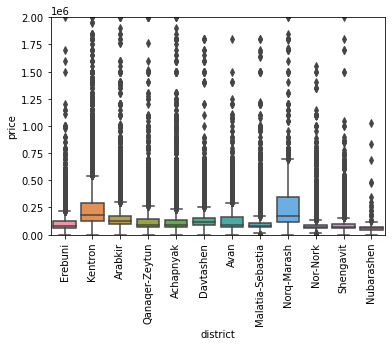

In [192]:
sns.boxplot(x='district', y='price', data=filtered_df)
plt.xticks(rotation=90)
plt.ylim(0, 2000000)

### Z-Score

In [194]:
from scipy import stats

# read in the data
#df = pd.read_csv('data.csv')

# group the data by district
grouped_data = filtered_df_copy.groupby('district')

# loop over each group and calculate the Z-score for price
for name, group in grouped_data:
   # print(group["district"])
    z = np.abs(stats.zscore(group['price']))
    #print(z)
    threshold = 2
    outliers = group[z > threshold]
    
    num_outliers = len(outliers)
    print(f"District {name} has {num_outliers} outliers")
    filtered_df_copy = filtered_df_copy.drop(outliers.index)

District Achapnyak has 62 outliers
District Arabkir has 12 outliers
District Avan has 3 outliers
District Davtashen has 28 outliers
District Erebuni has 9 outliers
District Kentron has 3 outliers
District Malatia-Sebastia has 26 outliers
District Nor-Nork has 24 outliers
District Norq-Marash has 45 outliers
District Nubarashen has 5 outliers
District Qanaqer-Zeytun has 19 outliers
District Shengavit has 10 outliers


In [195]:
filtered_df_copy

,OBJECTID,level_0,backup_status,index,id,price,rooms,square_meters,address,date,...,links,download_date,days_in,years_moths,y,x,nearest_station_id,nearest_station_name,walking_distance_to_metro(m),district
0,700755,822551,sold,3423,316,500000.0,4.0,150.0,"Yerevan, Erebuni, Davit Bek St",2022-08-08 20:25:49,...,https://www.real-estate.am/en/house-for-sale/D...,NaN,NaN,None_None,44.524808,40.148482,6,Sasuntsi Davit,2542,Erebuni
1,481959,552379,sold,2161,1055,130000.0,2.0,50.0,"Yerevan, Center, Vardanants St",2022-10-08 21:56:34,...,https://www.real-estate.am/en/1-bedroom/apartm...,2022-09-10 02:04:46,28.0,2022_9,44.521089,40.174314,4,Republic Square,921,Kentron
2,699792,821557,sold,2429,1991,95000.0,2.0,56.0,"Yerevan, Arabkir, V.Papazyan St",2022-08-08 20:25:49,...,https://www.real-estate.am/en/1-bedroom/apartm...,NaN,NaN,None_None,44.502252,40.204200,1,Barekamutyun,1196,Arabkir
3,700740,822536,sold,3408,3113,918000.0,4.0,600.0,"Yerevan, Arabkir, Babayan St",2022-08-08 20:25:49,...,https://www.real-estate.am/en/house-for-sale/B...,NaN,NaN,None_None,44.519823,40.199158,3,Yeritasardakan,2868,Qanaqer-Zeytun
4,482385,552814,sold,587,3119,400000.0,4.0,1150.0,"Yerevan, Vahagni district, Narekaci st",2022-10-08 21:56:34,...,https://www.real-estate.am/en/house-for-sale/N...,2022-09-25 12:31:44,13.0,2022_9,44.448497,40.220040,1,Barekamutyun,7018,Achapnyak
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88523,45120,54101,sold,851,19124548,990000.0,5.0,NaN,"Հյուսիսային ճառագայթ փողոց 1, Երևան",2023-03-14 15:26:36,...,http://list.am/en/item/19124548,2023-03-14 12:17:35,0.0,2023_3,44.516131,40.199785,2,Baghramyan,2935,Arabkir
88524,45113,54087,sold,837,19124552,210000.0,5.0,NaN,"Պարսեղովի փողոց, Երևան",2023-03-14 15:26:36,...,http://list.am/en/item/19124552,2023-03-14 11:47:42,0.0,2023_3,44.471134,40.199275,1,Barekamutyun,3128,Achapnyak
88525,45093,54029,sold,779,19124632,300000.0,4.0,NaN,"Ezras Hasratyan Street 32/20, Yerevan",2023-03-14 15:26:36,...,http://list.am/en/item/19124632,2023-03-14 11:43:07,0.0,2023_3,44.537852,40.214862,3,Yeritasardakan,5772,Qanaqer-Zeytun
88526,44758,53371,sold,121,19125622,215000.0,4.0,NaN,"Քանաքեռ 9-րդ փողոց 15/1, Երևան",2023-03-14 15:26:36,...,http://list.am/en/item/19125622,2023-03-14 11:35:27,0.0,2023_3,44.546763,40.185311,3,Yeritasardakan,3776,Norq-Marash


In [181]:
for name, group in grouped_data:
    q1 = group['price'].quantile(0.25)
    #print(q1)
    q3 = group['price'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = group[(group['price'] < lower_bound) | (group['price'] > upper_bound)]
    num_outliers = len(outliers)
    print(f"District {name} has {num_outliers} outliers")

District Achapnyak has 762 outliers
District Arabkir has 1291 outliers
District Avan has 384 outliers
District Davtashen has 408 outliers
District Erebuni has 363 outliers
District Kentron has 1632 outliers
District Malatia-Sebastia has 821 outliers
District Nor-Nork has 863 outliers
District Norq-Marash has 99 outliers
District Nubarashen has 20 outliers
District Qanaqer-Zeytun has 398 outliers
District Shengavit has 443 outliers


In [5]:
filtered_df_copy.drop(columns=['OBJECTID', 'level_0', 'index', 'years_moths', 'nearest_station_id'], inplace=True)
filtered_df_copy = filtered_df_copy.rename(columns={'date': 'sold_date', 'nearest_station_name': 'closest_metro'})

In [7]:
filtered_df_copy.to_excel("../data/yerevan_historical_clean/sale_historical.xlsx", index=False) # without outliers